In [13]:
DATASET_PATH = "/content/archive.zip"

In [14]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [16]:
import zipfile

with zipfile.ZipFile("/content/archive.zip", "r") as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Extraction completed!")

Extraction completed!


In [17]:
DATASET_PATH = "/content/dataset/PetImages"

In [32]:
IMG_SIZE = 64

X = []
y = []

categories = ["Cat", "Dog"]

for label, category in enumerate(categories):
    folder = os.path.join(DATASET_PATH, category)

    for file in os.listdir(folder):
        path = os.path.join(folder, file)

        try:
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            features = hog(
                img,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                feature_vector=True
            )

            X.append(features)
            y.append(label)

        except:
            continue

X = np.array(X)
y = np.array(y)

print("Total Images:", len(X))

Total Images: 24997


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
from sklearn.svm import LinearSVC

model = LinearSVC(C=2.0, max_iter=10000)
model.fit(X_train, y_train)

LinearSVC(C=2.0, max_iter=10000)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
model = LinearSVC(max_iter=5000)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [40]:
predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.7324
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      2500
           1       0.73      0.74      0.73      2500

    accuracy                           0.73      5000
   macro avg       0.73      0.73      0.73      5000
weighted avg       0.73      0.73      0.73      5000



In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1 Score : {f1 * 100:.2f}%")

Accuracy : 73.24%
Precision: 72.86%
Recall   : 74.08%
F1 Score : 73.46%


In [47]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predictions,
    target_names=["Cat", "Dog"]
))

              precision    recall  f1-score   support

         Cat       0.74      0.72      0.73      2500
         Dog       0.73      0.74      0.73      2500

    accuracy                           0.73      5000
   macro avg       0.73      0.73      0.73      5000
weighted avg       0.73      0.73      0.73      5000



In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)
print(cm)

[[1810  690]
 [ 648 1852]]


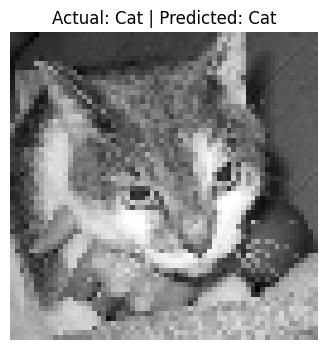

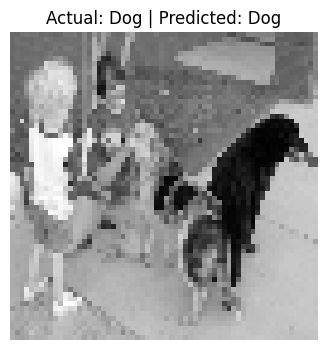

In [45]:
import os
import cv2
import random
import matplotlib.pyplot as plt
from skimage.feature import hog


DATASET_PATH = "/content/dataset/PetImages"


for i in range(2):
    category = random.choice(["Cat", "Dog"])
    folder = os.path.join(DATASET_PATH, category)


    while True:
        image_name = random.choice(os.listdir(folder))
        image_path = os.path.join(folder, image_name)

        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            break

    img = cv2.resize(img, (64, 64))


    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        feature_vector=True
    )

    prediction = model.predict([features])[0]
    predicted_label = "Dog" if prediction == 1 else "Cat"


    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap="gray")
    plt.title(f"Actual: {category} | Predicted: {predicted_label}")
    plt.axis("off")
    plt.show()